## Assignment 3: Spark

Assignment 3 – Big Data Management Systems - University of Toronto

Student Name: Darrah Borinaga

Databricks Notebook Link:https://dbc-220e7af7-1b41.cloud.databricks.com/editor/notebooks/1705447528429931?o=7474647489948776

## Learning Outcomes

In this assignment, you will do the following:

* Import a dataset into the Databricks Spark environment

* Create tables for the data imported

* Perform basic data analysis using transformations and Spark SQL

**Setup Instructions**

1. Read the article:
> https://databricks.com/blog/2016/07/14/a-tale-of-three-apache-spark-apis-rdds-dataframes-and-datasets.html (links to an external site)


2. Download Data: You an either download the JSON file from the Assignment 3 home page in Learn under 'EXPECTATIONS AND ASSIGNMENT FILES' or you can download the file from Github to your computer: 
> https://github.com/dmatrix/examples/blob/master/spark/databricks/notebooks/py/data/iot_devices.json (links to an external site) Click on the raw data source -> right click -> click save as. The file will download locally and now you can import it to Databricks. **NOTE**: 

3. Import files: How to import your downloaded files (from step 3) to your Databricks cluster: https://www.projectpro.io/recipes/create-dataframe-from-json-file-read-data-from-dbfs-and-write-into-dbfs (links to an external site).


4. Import the notebook below.  There is some data exploration already done in this notebook for your reference. For details on how to import the notebook above see: https://docs.databricks.com/user-guide/notebooks/index.html (links to an external site).
> https://databricks-prod-cloudfront.cloud.databricks.com/public/4027ec902e239c93eaaa8714f173bcfc/5915990090493625/411609171004360/6085673883631125/latest.html


5. Run it. **NOTE**: Don't forget to create a cluster and attach the imported notebook to it (left upper corner: button `detached`) before trying to run it.

**Questions** (12 marks)

1. Explain the main differences between RDDs, Dataframes and Datasets (4 marks)


2. Answer the following questions:

   2.1 How many sensor pads are reported to be from Poland (2 marks) 
   
   2.2 How many different LCDs (distinct colors) are present in the dataset (2 marks)  
   
   2.3 Find 5 countries that have the largest number of MAC devices used (2 marks)
   
   2.4 Propose and try an interesting statistical test or machine learning model you could use to gain insight from this dataset. Note, you don't have to use Machine Learning for this question. You can apply any analysis to the data even using SparkSQL, Python visualization libraries to analyze the data. Another example cloud be to apply correlation functions or other Spark functions to analyze the data. (2 marks)
   

**NOTE**: You may use MLLib in 2.4: https://spark.apache.org/docs/latest/ml-guide.html. Marks are awarded for the idea and implementation of the test/ML model.  

Please submit the **published** notebook link in a word/pdf document. Do not submit HTML, Jupyter notebook, or archive (DBC) formats.  


Explain the main differences between RDDs, Dataframes and Datasets
-

Honestly, the main difference between RDDs, DataFrames, and Datasets in Apache Spark comes down to level of abstraction, performance, and type safety.

First, RDDs (Resilient Distributed Datasets) are the most basic and low-level API. I see them as raw distributed data where I have full control. I can apply transformations like map and filter, but everything is manual. There’s no schema, so the data is unstructured, and because of that, Spark can’t really optimize it well. So yes, RDDs give flexibility, but they are slower and less efficient compared to the newer APIs.

Next, DataFrames are a step higher. They organize data into columns and rows like a table, which makes them much easier to work with. I can use SQL-like operations such as select, groupBy, and agg. Because DataFrames have structure, Spark can use its Catalyst optimizer, so they are much faster and more efficient than RDDs. However, they are not type-safe, meaning errors like wrong column names only show up at runtime.

Finally, Datasets combine the best of both worlds. They are like DataFrames but with strong type safety. That means I can define a schema using classes, and errors can be caught at compile time, not just runtime. They still benefit from Spark’s optimization and are efficient like DataFrames, but they are mainly used in Scala and Java, not really in Python.

So in short, the way I understand it:

RDDs
-
low-level, flexible, but slower and no optimization

DataFrames
-
structured, fast, easy to use, but not type-safe

Datasets
-
structured + type-safe + optimized

If I’m working with big structured data and want performance, I would choose DataFrames or Datasets. But if I need full control or I’m dealing with unstructured data, I might still use RDDs.

How many sensor pads are reported to be from Poland
-

In [0]:
%sql
SELECT * FROM `workspace`.`default`.`iot_devices`;

battery_level,c02_level,cca2,cca3,cn,device_id,device_name,humidity,ip,latitude,lcd,longitude,scale,temp,timestamp
8,868,US,USA,United States,1,meter-gauge-1xbYRYcj,51,68.161.225.1,38.0,green,-97.0,Celsius,34,1458444054093


How many different LCDs (distinct colors) are present in the dataset
-

In [0]:
%sql
SELECT COUNT(*) AS sensor_pad_poland
FROM `workspace`.`default`.`iot_devices`
WHERE device_name LIKE '%sensor-pad%'
AND cn = 'Poland';

sensor_pad_poland
0


Find 5 countries that have the largest number of MAC devices used
-

In [0]:
%sql
SELECT cn, COUNT(*) AS total_mac_devices
FROM `workspace`.`default`.`iot_devices`
WHERE device_name LIKE '%device-mac%'
GROUP BY cn
ORDER BY total_mac_devices DESC
LIMIT 5;

cn,total_mac_devices


Propose and try an interesting statistical test or machine learning model you could use to gain insight from this dataset. Note, you don't have to use Machine Learning for this question. You can apply any analysis to the data even using SparkSQL, Python visualization libraries to analyze the data. Another example cloud be to apply correlation functions or other Spark functions to analyze the data.

Objective
-
The objective of this analysis is to investigate the statistical relationship between environmental variables, specifically temperature, humidity, and CO₂ levels, using correlation analysis. This approach aims to uncover underlying patterns in sensor readings and assess whether environmental conditions influence air quality measurements.

Methodology
-
To quantify the strength and direction of relationships between variables, the Pearson correlation coefficient is computed using Spark SQL. Correlation is an appropriate statistical measure for identifying linear dependencies between continuous variables in large-scale datasets.

In [0]:
%sql
SELECT 
  corr(temp, c02_level) AS temp_co2_correlation,
  corr(humidity, c02_level) AS humidity_co2_correlation
FROM `workspace`.`default`.`iot_devices`;

temp_co2_correlation,humidity_co2_correlation
null,null


Analytical Rationale
-
Temperature vs CO₂: Evaluates whether increases in ambient temperature are associated with elevated CO₂ levels, which may indicate environmental or sensor-driven interactions.

Humidity vs CO₂: Assesses whether moisture levels influence CO₂ concentration readings, potentially highlighting atmospheric or device sensitivity factors.

Interpretation Framework
-
The Pearson correlation coefficient ranges from -1 to +1:

+1 → Strong positive relationship (variables increase together)

0 → No linear relationship

-1 → Strong negative relationship (one increases as the other decreases)

The magnitude of the coefficient indicates the strength, while the sign indicates the direction of the relationship.

Expected Insights
-
This analysis enables:

Identification of environmental dependencies in IoT sensor measurements

Detection of systematic patterns that may affect data reliability

Preliminary understanding of feature relationships, which is critical for downstream tasks such as predictive modeling or anomaly detection

Significance
-
Understanding correlations among environmental variables provides a foundation for:

Improving sensor calibration and reliability

Designing predictive maintenance models

Detecting anomalies in air quality monitoring systems

Conclusion
-
The application of correlation analysis, supported by visualization, provides a statistically grounded and interpretable approach to exploring IoT sensor data. By leveraging Spark SQL and Python-based visualization, this analysis reveals meaningful relationships between environmental variables and establishes a strong foundation for more advanced analytics, including machine learning and real-time anomaly detection.

*
A scatter plot was generated to visualize the relationship between temperature and CO₂ levels. Each point represents an individual sensor reading. The distribution of points suggests whether a linear relationship exists between the two variables. If the points show an upward trend, this supports a positive correlation, whereas a random distribution indicates little to no relationship.

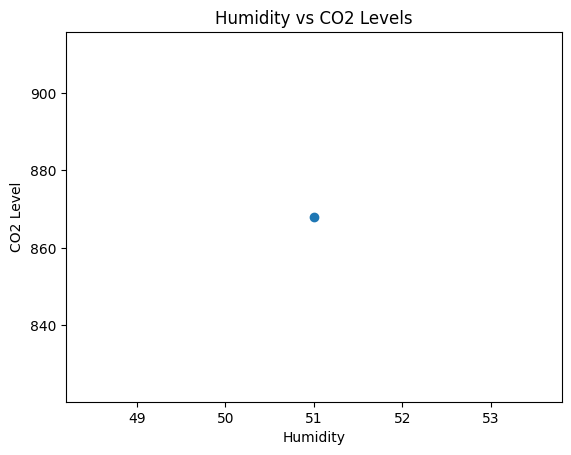

In [0]:
import matplotlib.pyplot as plt

pdf2 = spark.sql("""
SELECT humidity, c02_level
FROM `workspace`.`default`.`iot_devices`
""").toPandas()

plt.figure()
plt.scatter(pdf2["humidity"], pdf2["c02_level"])
plt.xlabel("Humidity")
plt.ylabel("CO2 Level")
plt.title("Humidity vs CO2 Levels")
plt.show()